### List of functions
- `random_state(d, L, complex=True)`: takes in the local/physical dimension `d`, number of sites `L` and whether the tensor should be real or complex, and outputs a vector of length $2^L$ representing the quantum state
- `vector_to_MPS(v, d, L)`: takes in a vector `v` of length $2^n$, physical dimension `d` and number of sites `L`, and outputs an array of tensors (the MPS) and the list of bond dimensions
  - also, automatically prints the dimensions of each core
- `mps_to_tensor(cores)`: takes in an MPS and converts it to a rank-L tensor
- `mps_to_vector(cores)`: takes in an MPS and converts it to a vector of length $2^L$
- `find_relative_error(v, cores)`: takes in the original vector `v` and an MPS `cores` and prints the relative error

In [16]:
v = random_state(4, 5)
cores, r = vector_to_MPS(v, 4, 5)
find_relative_error(v, cores)

[(1, 4, 4), (4, 4, 16), (16, 4, 16), (16, 4, 4), (4, 4, 1)]
relative error: 4.1105059375817656e-15


In [2]:
import numpy as np

In [3]:
def random_state(d, L, complex=True):
    dim = d**L
    if complex:
        v = np.random.randn(dim) + 1j*np.random.randn(dim)
    else:
        v = np.random.randn(dim)
        
    v /= np.linalg.norm(v)
    return v

    # random.rand() samples from [0,1)
    # random.randn() samples from (-\infty, \infty) with mean = 0 and variance = 1

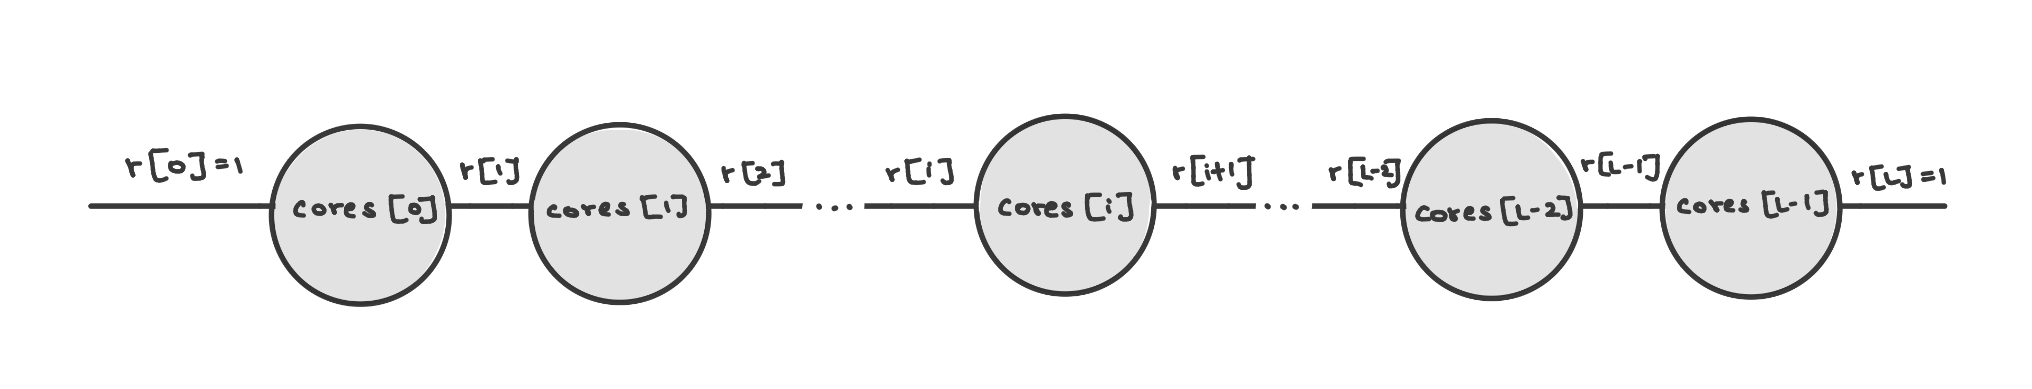

In [4]:
def vector_to_MPS(v, d, L):
    r = np.ones(L+1, dtype=int) # bond dimension between sites
    cores = []                  # the actual rank-3 tensor in each site
    T = v.reshape([d]*L)        # reshape input vector into a rank-L tensor
    
    for i in range(L-1):
        M = T.reshape(r[i]*d, -1)
        # the bond dimension r[i] is something like the number of different cases
        # so M is a table that tells something like "in a given case, when the qubit at site l is in |0> (or |1> for that matter),
        # what is the complex amplitude of each of the remaining possible arrangements?"
        
        U, S, Vh = np.linalg.svd(M, full_matrices=False) # SVD decomposition of M

        r[i+1] = U.shape[1]
        # entanglement (ie bond dimension, or number of different 'cases') is encoded by number of columns in U
        
        core = U.reshape(r[i], d, r[i+1])
        # this is the tensor that represents the qubit at each site
        # we reshape U into the correct structure: for a given qubit state in the site,
        # what is the complex amplitude (that squares to probability) that a case on the left results in a case on the right?
        
        cores.append(core)
    
        SVh = S[:, None] * Vh 
        # convert S to a column vector and broadcast (using *) it with Vh
        # identical to matrix multiplication (using @) of diagonal matrix S with Vh
        # SVh represents the tensor of the remaining qubits
        
        T = SVh.reshape(r[i+1], *([d] * (L - i - 1)))
        # reshape SVh to "for each bond index (for each case),
        # what is the complex amplitude of each of the possible remaining arrangements?"
        # check: why do we reshape to T only to reshape T to M immediately afterwards?

    lastCore = T.reshape(r[L-1], d, r[L]) 
    cores.append(lastCore)
    print([c.shape for c in cores])
    # the last tensor stored in T is the core at the L-th site, where r[L] = 1 anyway
    
    return cores, r

In [5]:
def mps_to_tensor(cores):
    X = cores[0]  # (1, d, r1)
    for k in range(1, len(cores)):
        # contract bond: last axis of X with first axis of next core
        X = np.tensordot(X, cores[k], axes=([-1], [0]))
    X = np.squeeze(X, axis=0)      # remove left boundary dim 1
    X = np.squeeze(X, axis=-1)     # remove right boundary dim 1
    return X  # (d, d, ..., d), ie rank-L tensor with each dimension having d elements

def mps_to_vector(cores):
    T = mps_to_tensor(cores)
    return T.reshape(-1)

def find_relative_error(v, cores):
    v_rec = mps_to_vector(cores) # stands for v_reconstructed (from the MPS)
    rel_err = np.linalg.norm(v - v_rec) / np.linalg.norm(v)
    print("relative error:", rel_err)